Notebook réalisé par Anthony Sureau

# Les imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from google.colab import drive
import itertools
import os
import glob
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filtrage des données

In [ ]:
drive.mount('/content/drive')

dossier = "/content/drive/MyDrive/redshift"
os.chdir(dossier)

# Lister tous les fichiers .npz du dossier
npz_files = glob.glob("*.npz")

# Filtrer uniquement les fichiers contenant "COSMOS"
cosmos_files = [f for f in npz_files if "COSMOS" in f]

# Charger chaque fichier dans un dictionnaire séparé
cosmos_data = {}
for fichier in cosmos_files:
    try:
        cosmos_data[fichier] = np.load(fichier, allow_pickle=True)
        print(f"Chargé : {fichier}")
    except Exception as e:
        print(f"Erreur lors du chargement de {fichier} : {e}")

# Afficher les clés et les shapes de chaque fichier séparément
for nom, data in cosmos_data.items():
    print(f"\n=== {nom} ===")
    for key in data.keys():
        print(f"  - {key} : {data[key].shape}")


# Séparer les fichiers COSMOS en deux groupes : spec et phot
spec_files = [f for f in cosmos_files if "spec" in f.lower()]
phot_files = [f for f in cosmos_files if "phot" in f.lower()]

print("Fichiers SPEC:", spec_files)
print("Fichiers PHOT:", phot_files)

# Charger les données spec
spec_data = np.load(spec_files[0], allow_pickle=True)

# Charger les données phot
phot_data = np.load(phot_files[0], allow_pickle=True)

# Voir ce qu'il y a dans chacun
print("\n=== SPEC ===")
for key in spec_data.keys():
    print(f"  - {key} : {spec_data[key].shape}")

print("\n=== PHOT ===")
for key in phot_data.keys():
    print(f"  - {key} : {phot_data[key].shape}")


# Extraire ce dont tu as besoin (adapte les noms des clés selon ce que tu vois)
spec_info = spec_data["info"]
phot_info = phot_data["info"]



# Convertir en DataFrame pandas pour faciliter la manipulation
spec_df = pd.DataFrame(spec_info)
phot_df = pd.DataFrame(phot_info)

# Renommer les colonnes cibles
spec_df = spec_df.rename(columns={"ZSPEC": "redshift"})
phot_df = phot_df.rename(columns={"ZPHOT": "redshift"})

# Vérifier
print("Colonnes SPEC:", spec_df.columns.tolist())
print("Colonnes PHOT:", phot_df.columns.tolist())

# Vérifier la colonne z dans chacun
print("\nSpec z:", spec_df["redshift"].head())
print("Phot z:", phot_df["redshift"].head())



# Garder uniquement les magnitudes
magnitudes = ['u', 'g', 'r', 'i', 'z', 'y','EBV']

spec_mag = spec_df[magnitudes + ['redshift']].copy()
phot_mag = phot_df[magnitudes + ['redshift']].copy()

# Créer les couleurs (différences entre magnitudes voisines)
for df in [spec_mag, phot_mag]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['z_y'] = df['z'] - df['y']

# Vérifier
print("Colonnes SPEC:", spec_mag.columns.tolist())
print(spec_mag.head())

print("\nColonnes PHOT:", phot_mag.columns.tolist())
print(phot_mag.head())


# Filtrer les données : garder uniquement redshift <= 1
#spec_mag = spec_mag[spec_mag['redshift'] <= 1].copy()
# phot_mag = phot_mag[phot_mag['redshift'] <= 1].copy()

print(f"SPEC après filtre : {len(spec_mag)} objets")
print(f"PHOT après filtre : {len(phot_mag)} objets")

# Vérifier
print("\nSpec redshift min/max:", spec_mag['redshift'].min(), spec_mag['redshift'].max())
print("Phot redshift min/max:", phot_mag['redshift'].min(), phot_mag['redshift'].max())


# 1. Vérifier les valeurs manquantes
print("=== Valeurs manquantes SPEC ===")
print(spec_mag.isnull().sum())

print("\n=== Valeurs manquantes PHOT ===")
print(phot_mag.isnull().sum())

# 2. Vérifier les valeurs infinies
print("\n=== Valeurs infinies SPEC ===")
print(np.isinf(spec_mag.select_dtypes(include=np.number)).sum())

print("\n=== Valeurs infinies PHOT ===")
print(np.isinf(phot_mag.select_dtypes(include=np.number)).sum())

# 3. Statistiques générales
print("\n=== Stats SPEC ===")
print(spec_mag.describe())

print("\n=== Stats PHOT ===")
print(phot_mag.describe())


# Les -99 sont des valeurs manquantes déguisées en astronomie
# On filtre toutes les lignes où une magnitude vaut -99

magnitudes = ['u', 'g', 'r', 'i', 'z', 'y','EBV']

# Remplacer les -99 par NaN puis supprimer ces lignes
# for df_name, df in [('spec_mag', spec_mag), ('phot_mag', phot_mag)]:
#   df.replace(-99, np.nan, inplace=True)
#   # Aussi capturer les valeurs proches de -99 (ex: -99.1, -99.05...
#   for col in magnitudes:
#     df.loc[df[col] < -90, col] = np.nan

spec_mag = spec_mag.dropna(subset=magnitudes).copy()
phot_mag = phot_mag.dropna(subset=magnitudes).copy()

# Recalculer les couleurs après nettoyage
for df in [spec_mag, phot_mag]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['z_y'] = df['z'] - df['y']

print(f"SPEC après nettoyage : {len(spec_mag)} objets")
print(f"PHOT après nettoyage : {len(phot_mag)} objets")

print("\n=== Stats SPEC ===")
print(spec_mag.describe())
print("\n=== Stats PHOT ===")
print(phot_mag.describe())


# Combiner les DEUX fichiers spec pour spec_mag
df_spec_list = []
for f in spec_files:
    d  = cosmos_data[f]
    df = pd.DataFrame(d['info'])
    df = df.rename(columns={"ZSPEC": "redshift"})
    df_spec_list.append(df)

spec_mag = pd.concat(df_spec_list, ignore_index=True)

# Nettoyage
magnitudes = ['u', 'g', 'r', 'i', 'z', 'y', 'EBV']
spec_mag = spec_mag.dropna(subset=magnitudes).copy()

# Recalculer les couleurs
spec_mag['u_g'] = spec_mag['u'] - spec_mag['g']
spec_mag['g_r'] = spec_mag['g'] - spec_mag['r']
spec_mag['r_i'] = spec_mag['r'] - spec_mag['i']
spec_mag['i_z'] = spec_mag['i'] - spec_mag['z']
spec_mag['z_y'] = spec_mag['z'] - spec_mag['y']

print(f"SPEC combiné : {len(spec_mag)} objets")  # doit afficher ~27

# Combiner les DEUX fichiers phot pour phot_mag
df_phot_list = []
for f in phot_files:
    d  = cosmos_data[f]
    df = pd.DataFrame(d['info'])
    df = df.rename(columns={"ZPHOT": "redshift"})
    df_phot_list.append(df)

phot_mag = pd.concat(df_phot_list, ignore_index=True)

# Nettoyage
phot_mag = phot_mag.dropna(subset=magnitudes).copy()

# Recalculer les couleurs
phot_mag['u_g'] = phot_mag['u'] - phot_mag['g']
phot_mag['g_r'] = phot_mag['g'] - phot_mag['r']
phot_mag['r_i'] = phot_mag['r'] - phot_mag['i']
phot_mag['i_z'] = phot_mag['i'] - phot_mag['z']
phot_mag['z_y'] = phot_mag['z'] - phot_mag['y']

print(f"PHOT combiné : {len(phot_mag)} objets")  # doit afficher ~12497

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Exception ignored in: <function NpzFile.__del__ at 0x7c07689d11c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: <function NpzFile.__del__ at 0x7c07689d11c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: <function NpzFile.__del__ at 0x7c07689d11c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/us

Chargé : COSMOS_v11_uijk_0001_photo_D.npz
Chargé : COSMOS_v11_uijk_0213_photo_UD.npz
Chargé : COSMOS_v11_uijk_0020_spec_D.npz
Chargé : COSMOS_v11_uijk_0073_spec_UD.npz

=== COSMOS_v11_uijk_0001_photo_D.npz ===
  - cube : (12054, 64, 64, 9)
  - info : (12054,)
  - flag : (12054, 9)

=== COSMOS_v11_uijk_0213_photo_UD.npz ===
  - cube : (443, 64, 64, 9)
  - info : (443,)
  - flag : (443, 9)

=== COSMOS_v11_uijk_0020_spec_D.npz ===
  - cube : (15, 64, 64, 9)
  - info : (15,)
  - flag : (15, 9)

=== COSMOS_v11_uijk_0073_spec_UD.npz ===
  - cube : (12, 64, 64, 9)
  - info : (12,)
  - flag : (12, 9)
Fichiers SPEC: ['COSMOS_v11_uijk_0020_spec_D.npz', 'COSMOS_v11_uijk_0073_spec_UD.npz']
Fichiers PHOT: ['COSMOS_v11_uijk_0001_photo_D.npz', 'COSMOS_v11_uijk_0213_photo_UD.npz']

=== SPEC ===
  - cube : (15, 64, 64, 9)
  - info : (15,)
  - flag : (15, 9)

=== PHOT ===
  - cube : (12054, 64, 64, 9)
  - info : (12054,)
  - flag : (12054, 9)
Colonnes SPEC: ['ID', 'RA', 'DEC', 'TRACT', 'PATCH', 'MASK', 

# Conformal Stat

In [ ]:
features = ['u', 'g', 'r', 'i', 'z', 'y', 'u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'EBV']

X = phot_mag[features].values
y = phot_mag['redshift'].values

print(f"Dataset complet : {X.shape[0]} objets")

Dataset complet : 12497 objets


# Calibration

In [ ]:
# split phot en train + calib

X_phot = phot_mag[features].values
y_phot = phot_mag['redshift'].values   # ZPHOT

X_train, X_calib, y_train, y_calib = train_test_split(
    X_phot, y_phot, test_size=0.3, random_state=42
)

# spec entier pour le test final

X_test = spec_mag[features].values
y_test = spec_mag['redshift'].values   # ZSPEC

print(f"Train      : {len(X_train)} objets  (phot / ZPHOT)")
print(f"Calibration: {len(X_calib)} objets  (phot / ZPHOT)")
print(f"Test       : {len(X_test)} objets   (spec / ZSPEC)")

# entraîner sur train phot

model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
model.fit(X_train, y_train)

# calibration conforme sur calib phot

y_calib_pred = model.predict(X_calib)
residuals    = np.abs(y_calib - y_calib_pred)

alpha   = 0.1
n_calib = len(residuals)
k       = int(np.ceil((1 - alpha) * (n_calib + 1))) - 1
k       = min(k, n_calib - 1)
q_hat   = np.sort(residuals)[k]

print(f"\nq_hat : {q_hat:.4f}")

# évaluation finale sur spec (ZSPEC)

y_test_pred = model.predict(X_test)

lower    = y_test_pred - q_hat
upper    = y_test_pred + q_hat
coverage = np.mean((y_test >= lower) & (y_test <= upper))

print(f"Couverture test : {coverage:.3f}  (cible >= {1 - alpha:.2f})")
print(f"Largeur moyenne : {np.mean(upper - lower):.4f}")

delta_z      = (y_test_pred - y_test) / (1 + y_test)
bias         = np.mean(delta_z)
sigma_nmad   = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
outlier_rate = np.sum(np.abs(delta_z) > 0.15) / len(delta_z) * 100

print(f"Bias        : {bias:.4f}")
print(f"Sigma_NMAD  : {sigma_nmad:.4f}")
print(f"Outlier rate: {outlier_rate:.2f}%")

Train      : 8747 objets  (phot / ZPHOT)
Calibration: 3750 objets  (phot / ZPHOT)
Test       : 27 objets   (spec / ZSPEC)

q_hat : 1.3205
Couverture test : 0.370  (cible >= 0.90)
Largeur moyenne : 2.6409
Bias        : 1.0626
Sigma_NMAD  : 1.4329
Outlier rate: 88.89%


In [ ]:
print("=== DONNÉES RIDGE + CONFORMAL ===")
print(f"Train      : {len(X_train)} objets  (phot / ZPHOT)")
print(f"Calibration: {len(X_calib)} objets  (phot / ZPHOT)")
print(f"Test       : {len(X_test)} objets   (spec / ZSPEC)")
print()
print(f"--- Conformal ---")
print(f"  n_calib  : {len(residuals)} résidus")
print(f"  q_hat    : {q_hat:.4f}")
print()
print(f"--- Features ---")
print(f"  {features}")

=== DONNÉES RIDGE + CONFORMAL ===
Train      : 8747 objets  (phot / ZPHOT)
Calibration: 3750 objets  (phot / ZPHOT)
Test       : 27 objets   (spec / ZSPEC)

--- Conformal ---
  n_calib  : 3750 résidus
  q_hat    : 1.3205

--- Features ---
  ['u', 'g', 'r', 'i', 'z', 'y', 'u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'EBV']


# Figure

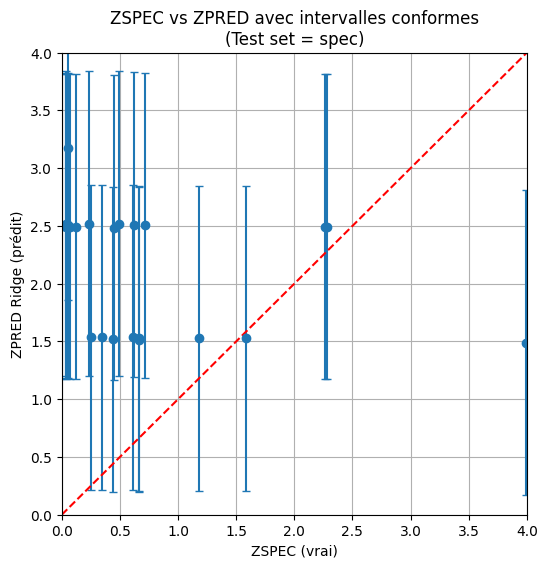

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

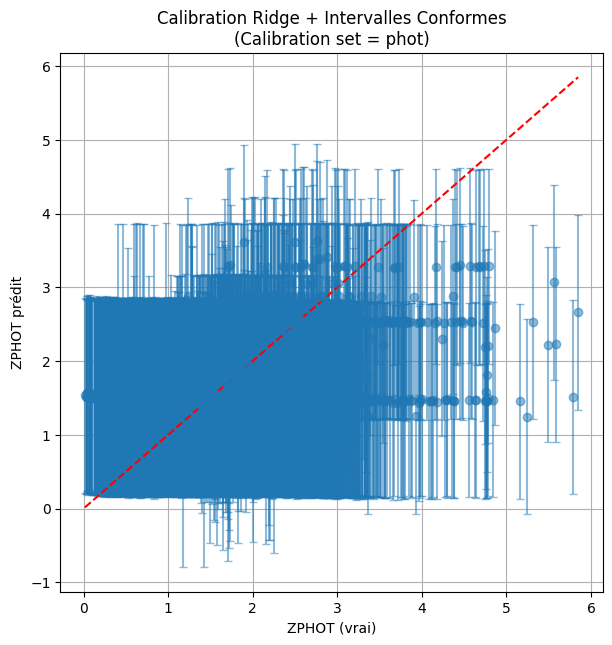

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

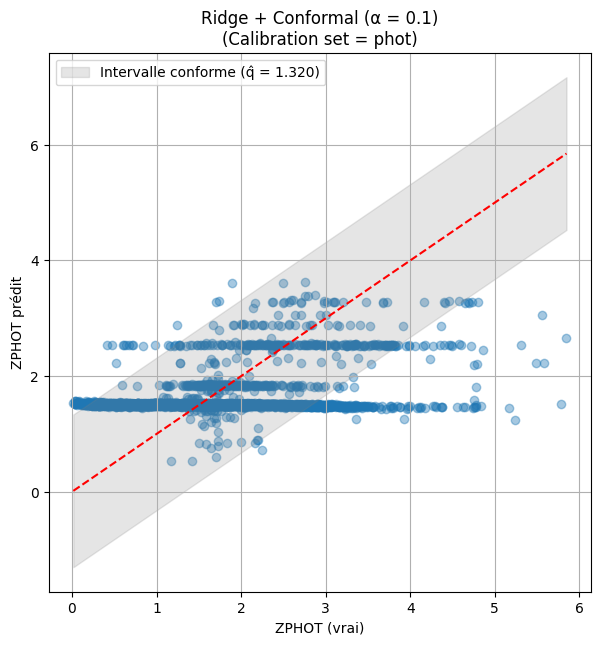

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

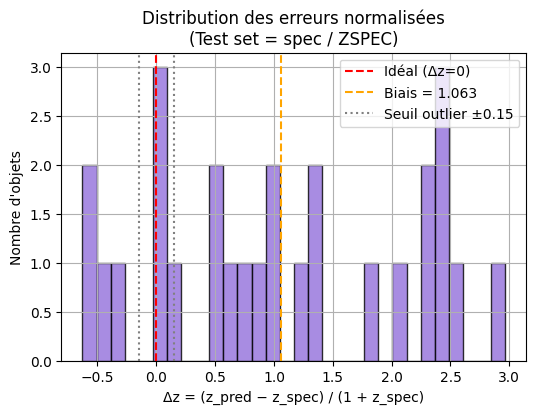

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Graphique 1 : ZSPEC vs ZPRED sur le test set (spec)

plt.figure(figsize=(6, 6))
plt.errorbar(
    y_test, y_test_pred,
    yerr=q_hat, fmt='o', capsize=3
)
plt.plot([0, 4], [0, 4], 'r--')
plt.xlabel("ZSPEC (vrai)")
plt.ylabel("ZPRED Ridge (prédit)")
plt.title("ZSPEC vs ZPRED avec intervalles conformes\n(Test set = spec)")
plt.xlim(0, 4); plt.ylim(0, 4)
plt.grid(True)
plt.savefig("graphique1_zspec_vs_zpred.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("graphique1_zspec_vs_zpred.png")

# Graphique 2 : ZPHOT vs ZPRED sur le set de calibration (phot)

y_pred_calib = model.predict(X_calib).ravel()
lower = y_pred_calib - q_hat
upper = y_pred_calib + q_hat

plt.figure(figsize=(7, 7))
plt.errorbar(
    y_calib, y_pred_calib,
    yerr=q_hat, fmt='o', alpha=0.5, capsize=3
)
plt.plot(
    [y_calib.min(), y_calib.max()],
    [y_calib.min(), y_calib.max()],
    'r--'
)
plt.xlabel("ZPHOT (vrai)")
plt.ylabel("ZPHOT prédit")
plt.title("Calibration Ridge + Intervalles Conformes\n(Calibration set = phot)")
plt.grid(True)
plt.savefig("graphique2_ridge_calib.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("graphique2_ridge_calib.png")

# Graphique 3 : scatter + bande conforme sur calibration (phot)

plt.figure(figsize=(7, 7))
plt.scatter(y_calib, y_pred_calib, alpha=0.4)
plt.plot(
    [y_calib.min(), y_calib.max()],
    [y_calib.min(), y_calib.max()],
    'r--'
)
plt.fill_between(
    np.linspace(y_calib.min(), y_calib.max(), 100),
    np.linspace(y_calib.min(), y_calib.max(), 100) - q_hat,
    np.linspace(y_calib.min(), y_calib.max(), 100) + q_hat,
    color='gray', alpha=0.2, label=f'Intervalle conforme (q̂ = {q_hat:.3f})'
)
plt.xlabel("ZPHOT (vrai)")
plt.ylabel("ZPHOT prédit")
plt.title("Ridge + Conformal (α = 0.1)\n(Calibration set = phot)")
plt.legend()
plt.grid(True)
plt.savefig("graphique3_scatter_conforme.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("graphique3_scatter_conforme.png")

# Graphique 4 : distribution des Δz sur le test set (spec)

delta_z = (y_test_pred - y_test) / (1 + y_test)

plt.figure(figsize=(6, 4))
plt.hist(delta_z, bins=30, color='mediumpurple', edgecolor='black', alpha=0.8)
plt.axvline(0,    color='red',    linestyle='--', label='Idéal (Δz=0)')
plt.axvline(bias, color='orange', linestyle='--', label=f'Biais = {bias:.3f}')
plt.axvline( 0.15, color='gray', linestyle=':', label='Seuil outlier ±0.15')
plt.axvline(-0.15, color='gray', linestyle=':')
plt.xlabel("Δz = (z_pred − z_spec) / (1 + z_spec)")
plt.ylabel("Nombre d'objets")
plt.title("Distribution des erreurs normalisées\n(Test set = spec / ZSPEC)")
plt.legend()
plt.grid(True)
plt.savefig("graphique4_delta_z.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("graphique4_delta_z.png")